# Decision Trees in Profondità

## Overfitting, Tuning e Pruning

In questo notebook esploriamo come ottimizzare un Decision Tree usando il dataset **Pima Indians Diabetes**, un dataset reale che presenta le sfide tipiche dei problemi di classificazione: rumore, classi sbilanciate e features non perfettamente discriminanti.

---
## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

plt.style.use('seaborn-v0_8-whitegrid')

---
## 2. Il Dataset: Pima Indians Diabetes

### 2.1 Descrizione

Questo dataset proviene dal National Institute of Diabetes and Digestive and Kidney Diseases. L'obiettivo è predire se una paziente ha il diabete basandosi su alcune misurazioni diagnostiche.

**Caratteristiche:**
- 768 pazienti (tutte donne di origine Pima, almeno 21 anni)
- 8 features mediche
- 2 classi: diabete positivo o negativo
- Classi sbilanciate: circa 35% positive, 65% negative

In [ ]:
# Caricare il dataset
diabetes = fetch_openml(name='diabetes', version=1, as_frame=True, parser='auto')

X = diabetes.data
y = (diabetes.target == 'tested_positive').astype(int)

print(f"Campioni: {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"\nNomi features: {list(X.columns)}")

Campioni: 768
Features: 8

Nomi features: ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']


In [3]:
# Approfondimento sulla creazione dell y
# inizialmente nel dataset il target è una stringa, che può assumere valori 'tested_positive' o 'tested_negative'
print("Situazione iniziale del target:")
print(diabetes.target)

# usiamo un filtro booleano per convertire la stringa in un valore numerico. In particolare assegnam True a 'tested_positive' e False a 'tested_negative'
print("\nFiltro booleano per 'tested_positive':")
print(diabetes.target == 'tested_positive')

# in seguito convertiamo i valori booleani in interi, ottenendo 1 per 'tested_positive' e 0 per 'tested_negative'
print("\nConversione in interi (1 per 'tested_positive', 0 per 'tested_negative'):")
print((diabetes.target == 'tested_positive').astype(int))

Situazione iniziale del target:
0      tested_positive
1      tested_negative
2      tested_positive
3      tested_negative
4      tested_positive
            ...       
763    tested_negative
764    tested_negative
765    tested_negative
766    tested_positive
767    tested_negative
Name: class, Length: 768, dtype: category
Categories (2, object): ['tested_negative', 'tested_positive']

Filtro booleano per 'tested_positive':
0       True
1      False
2       True
3      False
4       True
       ...  
763    False
764    False
765    False
766     True
767    False
Name: class, Length: 768, dtype: bool

Conversione in interi (1 per 'tested_positive', 0 per 'tested_negative'):
0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: class, Length: 768, dtype: int64


In [4]:
# Distribuzione delle classi, per stamparla utilizziamo un nuovo filtro booleano
# possiamo applicare filtri booleani ai tipici array di numpy o alle serie di pandas, in questo caso y è una serie di pandas
print(type(y))

print("\nDistribuzione classi:")
print(f"  Negativo (0): {(y == 0).sum()} ({(y == 0).mean():.1%})")
print(f"  Positivo (1): {(y == 1).sum()} ({(y == 1).mean():.1%})")

<class 'pandas.core.series.Series'>

Distribuzione classi:
  Negativo (0): 500 (65.1%)
  Positivo (1): 268 (34.9%)


### 2.2 Le Features

| Feature | Descrizione |
|---------|-------------|
| preg | Numero di gravidanze |
| plas | Concentrazione di glucosio nel plasma (test tolleranza glucosio) |
| pres | Pressione sanguigna diastolica (mm Hg) |
| skin | Spessore della plica cutanea del tricipite (mm) |
| insu | Insulina sierica a 2 ore (mu U/ml) |
| mass | Indice di massa corporea (BMI) |
| pedi | Diabetes Pedigree Function (storia familiare) |
| age | Età (anni) |

In [5]:
# Prime righe del dataset
df = X.copy()
# Domanda: perchè copy() e non direttamente df = X?

df['diabetes'] = y
df.head(10)

,preg,plas,pres,skin,insu,mass,pedi,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [6]:
# # Statistiche descrittive
X.describe()

,preg,plas,pres,skin,insu,mass,pedi,age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


### 2.3 Visualizzare il dataset

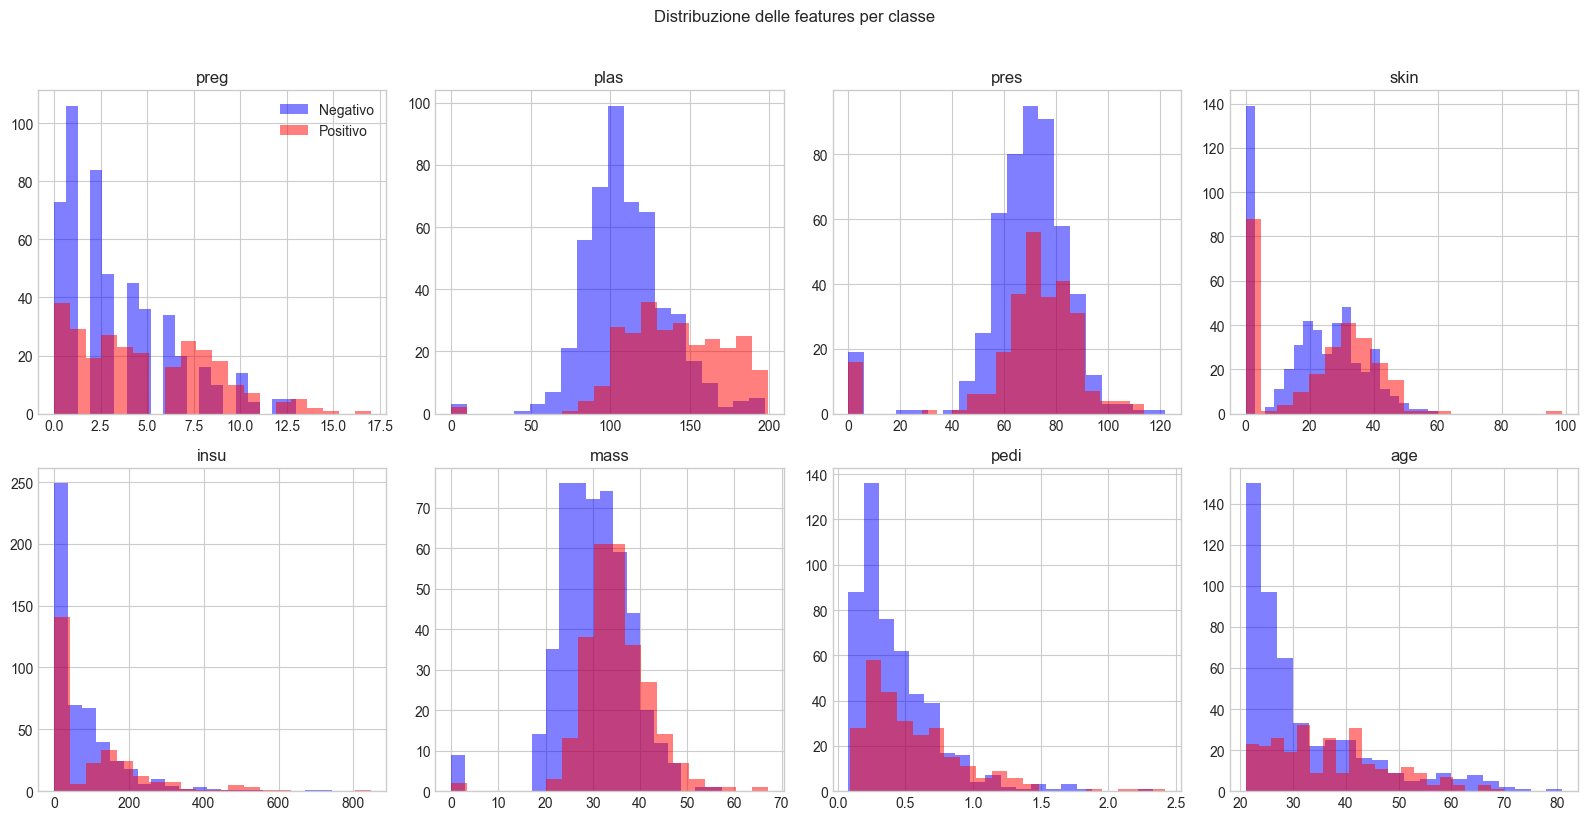

In [7]:
# Distribuzione delle features per classe
# creiamo una griglia di grafici 2 righe per 4 colonne
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Cicliamo su ogni feature (contenuta in X.columns) e sull'asse corrispondente (ax)
for i, (col, ax) in enumerate(zip(X.columns, axes.flat)):
    # alpha indica la trasparenza delle barre
    # bins indica il numero di intervalli dell'istogramma sulla x (quante barre mostrare)
    ax.hist(X.loc[y == 0, col], bins=20, alpha=0.5, label='Negativo', color='blue')
    ax.hist(X.loc[y == 1, col], bins=20, alpha=0.5, label='Positivo', color='red')
    ax.set_title(col)
    if i == 0:
        ax.legend()

plt.suptitle('Distribuzione delle features per classe', y=1.02)
plt.tight_layout()
plt.show()

**Osservazione:** Le distribuzioni si sovrappongono molto. Alcune features come `plas` (glucosio) e `age` mostrano una separazione maggiore, ma nessuna feature da sola separa perfettamente le classi. Questo è tipico dei problemi reali.

#### Approfondimento su .flat

Nella creazione del grafico abbiamo usato l'istruzione .flat(). A cosa serve?

``for i, (col, ax) in enumerate(zip(X.columns, axes.flat))``

plt.subplots(2, 4) restituisce una matrice 2D di assi, ma per ciclare con un for ci serve una lista 1D.

```
axes = [
    [ax0, ax1, ax2, ax3],   # riga 0
    [ax4, ax5, ax6, ax7]    # riga 1
]
```

Per accedere dovremmo scrivere axes[0][0], axes[0][1], ecc., il che è scomodo nel ciclo!
Inoltre stiamo utilizzando axes nella funzione zip, che associa ogni valore del primo parametro (X.columns), ad un valore del secondo parametro (appunto axes).

La soluzione è usare flat() che "appiattisce" la matrice
axes.flat = [ax0, ax1, ax2, ax3, ax4, ax5, ax6, ax7]

Ora per ogni elemento di X.columns (le nostre feature), associamo un asse.

zip ritornerà: 
```[(preg,ax0), (plas,ax1), (pres,ax2), ...]```


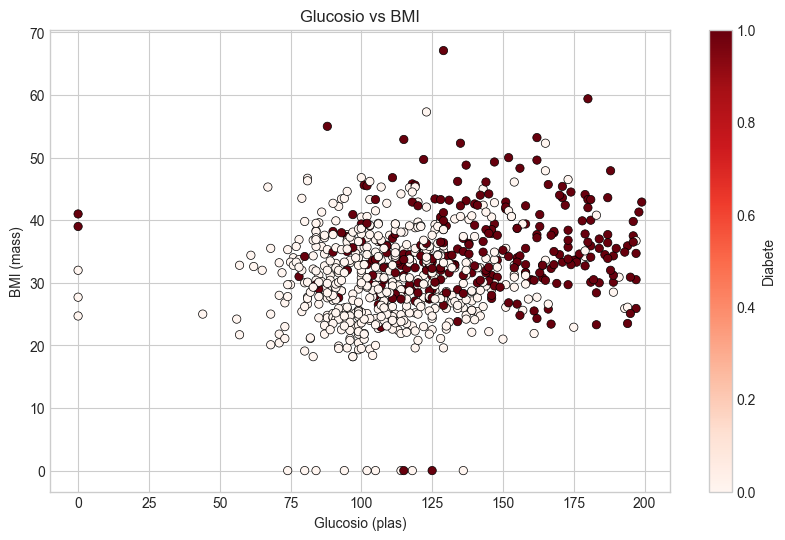

In [8]:
# Scatter plot: glucosio vs BMI (due features importanti)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X['plas'], X['mass'], c=y, cmap='Reds', alpha=1, 
                      edgecolors='black', 
                      linewidth=0.5)
plt.colorbar(scatter, label='Diabete')
plt.xlabel('Glucosio (plas)')
plt.ylabel('BMI (mass)')
plt.title('Glucosio vs BMI')
plt.show()

### 2.4 Train/Test Split

In [9]:
# Convertiamo a numpy array per sklearn
print(type(X))
print(type(y))
X_array = X.values
y_array = y.values
print(type(X_array))
print(type(y_array))

X_train, X_test, y_train, y_test = train_test_split(
    X_array, y_array, test_size=0.2, random_state=42, stratify=y_array
)

print(f"Training: {X_train.shape[0]} campioni")
print(f"Test: {X_test.shape[0]} campioni")

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Training: 614 campioni
Test: 154 campioni


---
## 3. Il Problema: Overfitting

In [10]:
# Albero senza limiti
tree_default = DecisionTreeClassifier(random_state=42)
tree_default.fit(X_train, y_train)

print(f"Accuracy TRAIN: {tree_default.score(X_train, y_train):.3f}")
print(f"Accuracy TEST:  {tree_default.score(X_test, y_test):.3f}")
print(f"\nProfondità: {tree_default.get_depth()}")
print(f"Numero nodi: {tree_default.tree_.node_count}")

Accuracy TRAIN: 1.000
Accuracy TEST:  0.727

Profondità: 16
Numero nodi: 229


**Osservazione:** 100% sul training, ma solo ~72% sul test.

Il gap di ~28% è molta grande! L'albero ha memorizzato il training set ma non riesce a generalizzare. Questo è **overfitting**.

#### Approfondimento




Come trovo i nomi degli attributi dell'albero che potrebbero essermi utili?

La fonte principale è la documentazione, in questo caso la pagina https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier


In particolare tra gli attributi troviamo tree_

tree_: Tree instance
The underlying Tree object. Please refer to **help(sklearn.tree._tree.Tree)** for attributes of Tree object and Understanding the decision tree structure for basic usage of these attributes.

In [11]:
import sklearn
help(sklearn.tree._tree.Tree)

Help on class Tree in module sklearn.tree._tree:

class Tree(builtins.object)
 |  Array-based representation of a binary decision tree.
 |
 |  The binary tree is represented as a number of parallel arrays. The i-th
 |  element of each array holds information about the node `i`. Node 0 is the
 |  tree's root. You can find a detailed description of all arrays in
 |  `_tree.pxd`. NOTE: Some of the arrays only apply to either leaves or split
 |  nodes, resp. In this case the values of nodes of the other type are
 |  arbitrary!
 |
 |  Attributes
 |  ----------
 |  node_count : intp_t
 |      The number of nodes (internal nodes + leaves) in the tree.
 |
 |  capacity : intp_t
 |      The current capacity (i.e., size) of the arrays, which is at least as
 |      great as `node_count`.
 |
 |  max_depth : intp_t
 |      The depth of the tree, i.e. the maximum depth of its leaves.
 |
 |  children_left : array of intp_t, shape [node_count]
 |      children_left[i] holds the node id of the left chil

---
## 4. Pre-Pruning: Limitare la Crescita

### 4.1 Il parametro max_depth

In [12]:
# Provare diverse profondità
print("depth    train    test     nodi")
print("-" * 35)

for depth in [1, 2, 3, 4, 5, 7, 10, None]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    
    train_acc = tree.score(X_train, y_train)
    test_acc = tree.score(X_test, y_test)
    n_nodes = tree.tree_.node_count
    
    depth_str = str(depth) if depth else "None"
    print(f"{depth_str:5s}    {train_acc:.3f}    {test_acc:.3f}    {n_nodes}")

depth    train    test     nodi
-----------------------------------
1        0.761    0.695    3
2        0.764    0.695    7
3        0.767    0.695    13
4        0.796    0.799    23
5        0.824    0.792    39
7        0.875    0.766    91
10       0.951    0.734    165
None     1.000    0.727    229


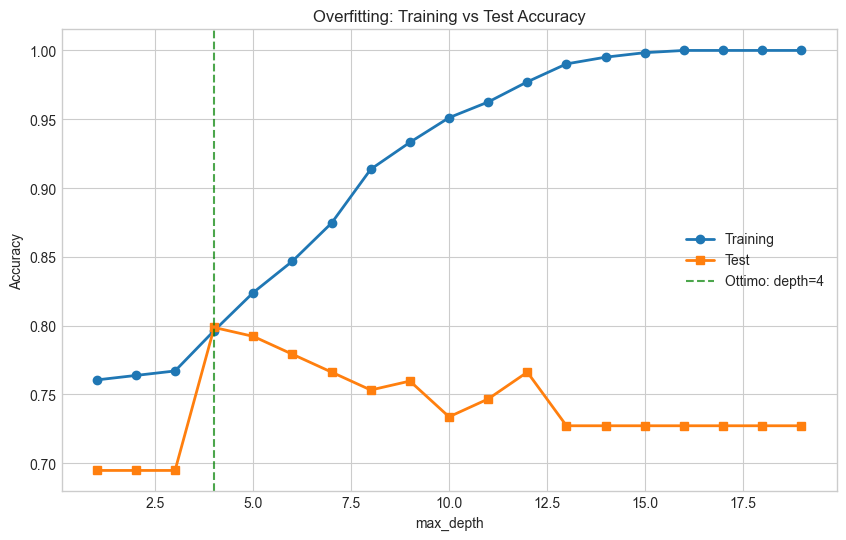

Migliore max_depth: 4 (test accuracy: 0.799)


In [13]:
# Visualizzare train vs test al variare di max_depth
depths = range(1, 20)
train_scores = []
test_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))

plt.figure(figsize=(10, 6))
# o- e s- indicano il tipo di marker per i punti, linewidth e markersize impostano lo spessore delle linee e la dimensione dei marker
plt.plot(depths, train_scores, 'o-', label='Training', linewidth=2, markersize=6)
plt.plot(depths, test_scores, 's-', label='Test', linewidth=2, markersize=6)

# Evidenziare il punto ottimale
best_depth = depths[np.argmax(test_scores)]
best_test = max(test_scores)
plt.axvline(best_depth, color='green', linestyle='--', alpha=0.7, label=f'Ottimo: depth={best_depth}')


plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Overfitting: Training vs Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print(f"Migliore max_depth: {best_depth} (test accuracy: {best_test:.3f})")

**Osservazione:**
- **training accuracy** sale continuamente fino al 100%
- **test accuracy** ha un picco intorno a depth=4, poi scende o si stabilizza
- Il gap tra le curve indica overfitting: l'albero impara i dettagli del training set invece di pattern generali

### 4.2 Altri parametri di pre-pruning


#### min_samples_split

È il numero minimo di campioni che un nodo deve avere per poter essere diviso ulteriormente.

**Default: 2** (basta che ci siano 2 campioni per tentare uno split)

Esempio con `min_samples_split=20`:
- Un nodo con 25 campioni → può essere diviso
- Un nodo con 15 campioni → diventa automaticamente una foglia, non si divide più


In [ ]:
# # min_samples_split: minimo campioni per fare uno split
# print("min_samples_split    train    test")
# print("-" * 40)

# for min_split in [2, 5, 10, 20, 50, 100]:
#     tree = DecisionTreeClassifier(min_samples_split=min_split, random_state=42)
#     tree.fit(X_train, y_train)
#     print(f"{min_split:17d}    {tree.score(X_train, y_train):.3f}    {tree.score(X_test, y_test):.3f}")

min_samples_split    train    test
----------------------------------------
                2    1.000    0.727
                5    0.963    0.714
               10    0.919    0.714
               20    0.879    0.734
               50    0.831    0.760
              100    0.796    0.799


**Osservazioni:**

- Con `min_samples_split=2` (default): 100% train, 72.7% test → overfitting classico
- Con `min_samples_split=100`: 79.6% train, 79.9% test → il gap scompare!

Il trend è chiaro: aumentando `min_samples_split`, il modello diventa più semplice. Perde accuratezza sul training ma la guadagna sul test.

Il caso `min_samples_split=100` è particolarmente interessante: il test supera addirittura il train. Questo indica un modello molto semplice che generalizza bene, senza memorizzare i dati di training.


#### min_samples_leaf

È il numero minimo di campioni che devono finire in ogni foglia dopo uno split.

**Default: 1** (anche una foglia con 1 solo campione è permessa)

Esempio con `min_samples_leaf=10`:
- Uno split che crea due foglie con 30 e 12 campioni → permesso
- Uno split che crea due foglie con 35 e 7 campioni → bloccato (7 < 10)

In [14]:
# min_samples_leaf: minimo campioni in ogni foglia
print("min_samples_leaf    train    test")
print("-" * 40)

for min_leaf in [1, 2, 5, 10, 20, 50]:
    tree = DecisionTreeClassifier(min_samples_leaf=min_leaf, random_state=42)
    tree.fit(X_train, y_train)
    print(f"{min_leaf:16d}    {tree.score(X_train, y_train):.3f}    {tree.score(X_test, y_test):.3f}")

min_samples_leaf    train    test
----------------------------------------
               1    1.000    0.727
               2    0.943    0.721
               5    0.893    0.747
              10    0.834    0.753
              20    0.813    0.773
              50    0.790    0.734


**Osservazioni:**

- Con `min_samples_leaf=1` (default): 100% train, 72.7% test → overfitting
- Il picco sul test è a `min_samples_leaf=20`: 81.3% train, 77.3% test

A differenza di `min_samples_split`, qui c'è un **punto ottimale**: aumentando troppo (50) test accuracy scende. Il modello diventa troppo semplice e inizia a fare **underfitting**.


**Nota sui valori:**

Con ~600 campioni nel training set, `min_samples_split=100` è un valore abbastanza aggressivo.

Una regola empirica comune è:
- `min_samples_split`: 1-5% del training set (per noi: 6-30)
- `min_samples_leaf`: 0.5-2% del training set (per noi: 3-12)

Il fatto che 100 funzioni bene qui è una peculiarità di questo dataset (rumoroso, poche features, classi sbilanciate). Non è una regola generale: i valori ottimali dipendono sempre dal dataset specifico.

---
## 5. Post-Pruning: Cost-Complexity Pruning

Approccio diverso: lasciamo crescere l'albero completamente, poi tagliamo i rami che non contribuiscono abbastanza.

Il parametro **ccp_alpha** (cost-complexity pruning alpha) controlla il trade-off:
- ccp_alpha = 0 → nessun pruning, albero completo
- ccp_alpha grande → pruning aggressivo, albero piccolo

L'idea è penalizzare la complessità: ogni nodo in più deve "guadagnarsi" il suo posto migliorando abbastanza l'accuratezza.

In [15]:
# Trovare i valori di alpha che producono alberi diversi
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

# Con la funzione cost_complexity_pruning_path otteniamo i valori di alpha che ci permettono di ottenere alberi potai
path = tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(f"Valori di alpha trovati: {len(ccp_alphas)}")
print(f"Range: {ccp_alphas[0]:.6f} - {ccp_alphas[-1]:.6f}")

Valori di alpha trovati: 59
Range: 0.000000 - 0.092254


Cosa vuol dire?

In pratica ci sono 59 diverse "versioni" dell'albero, ottenute dall'albero completo potando via via i nodi.

Si parte dall'albero completo e si calcola, per ogni nodo interno, quanto "costa" tenerlo rispetto a quanto migliora l'accuratezza.
Quindi i valori di alpha trovati, non sono valori a caso: sono i punti esatti dove conviene tagliare un ramo specifico. Ogni valore corrisponde a un nodo che "non vale il suo costo".

In [ ]:
# Addestrare un albero per ogni valore di alpha
trees = []
for alpha in ccp_alphas:
    tree = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    tree.fit(X_train, y_train)
    trees.append(tree)

# Calcolare le metriche per ogni albero
train_scores = [t.score(X_train, y_train) for t in trees]
test_scores = [t.score(X_test, y_test) for t in trees]
node_counts = [t.tree_.node_count for t in trees]

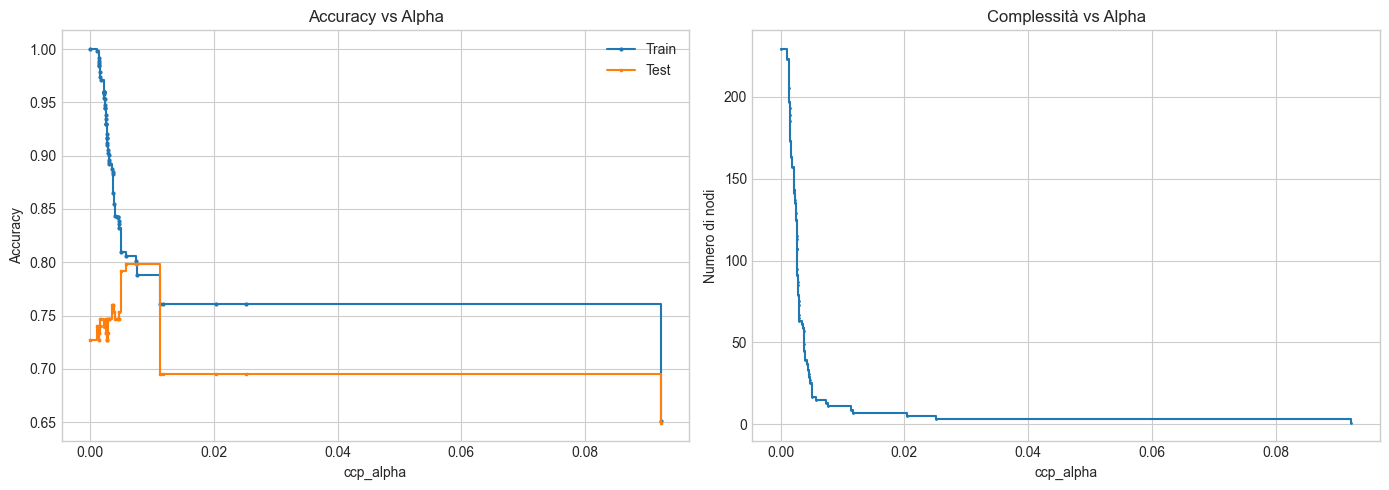

In [ ]:
# Visualizzare accuracy vs alpha
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Grafico 1: Accuracy
axes[0].plot(ccp_alphas, train_scores, marker='o', label='Train', 
             drawstyle='steps-post', markersize=2)
axes[0].plot(ccp_alphas, test_scores, marker='s', label='Test', 
             drawstyle='steps-post', markersize=2)
axes[0].set_xlabel('ccp_alpha')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Alpha')
axes[0].legend()

# Grafico 2: Numero di nodi
axes[1].plot(ccp_alphas, node_counts, marker='o', drawstyle='steps-post', markersize=1)
axes[1].set_xlabel('ccp_alpha')
axes[1].set_ylabel('Numero di nodi')
axes[1].set_title('Complessità vs Alpha')

plt.tight_layout()
plt.show()

In [19]:
# Trovare l'alpha ottimale
best_idx = np.argmax(test_scores)
best_alpha = ccp_alphas[best_idx]

print(f"Migliore alpha: {best_alpha:.6f}")
print(f"Test accuracy: {test_scores[best_idx]:.3f}")
print(f"Train accuracy: {train_scores[best_idx]:.3f}")
print(f"Numero nodi: {node_counts[best_idx]}")

Migliore alpha: 0.005776
Test accuracy: 0.799
Train accuracy: 0.806
Numero nodi: 15


---
## 6. Confronto Finale

In [20]:
# Addestrare i modelli da confrontare
tree_default = DecisionTreeClassifier(random_state=42)
tree_default.fit(X_train, y_train)

tree_depth = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_depth.fit(X_train, y_train)

tree_pruned = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
tree_pruned.fit(X_train, y_train)

# Confronto
print("Modello              Train    Test     Nodi   Profondità")
print("=" * 60)

for name, tree in [('Default', tree_default), 
                   ('max_depth=4', tree_depth), 
                   ('ccp_alpha', tree_pruned)]:
    train = tree.score(X_train, y_train)
    test = tree.score(X_test, y_test)
    nodes = tree.tree_.node_count
    depth = tree.get_depth()
    print(f"{name:20s} {train:.3f}    {test:.3f}    {nodes:4d}   {depth}")

Modello              Train    Test     Nodi   Profondità
Default              1.000    0.727     229   16
max_depth=4          0.796    0.799      23   4
ccp_alpha            0.806    0.799      15   5


**Osservazione:** 
- Il **default** ha 100% train ma bassa accuracy sul test → overfitting grave
- Con **pruning** (sia pre che post): train più basso ma test più alto → generalizza meglio
- Modelli più semplici (meno nodi) spesso performano meglio sui dati nuovi

---
## 7. Interpretabilità

Uno dei grandi vantaggi dei Decision Trees: possiamo capire esattamente come prendono le decisioni.

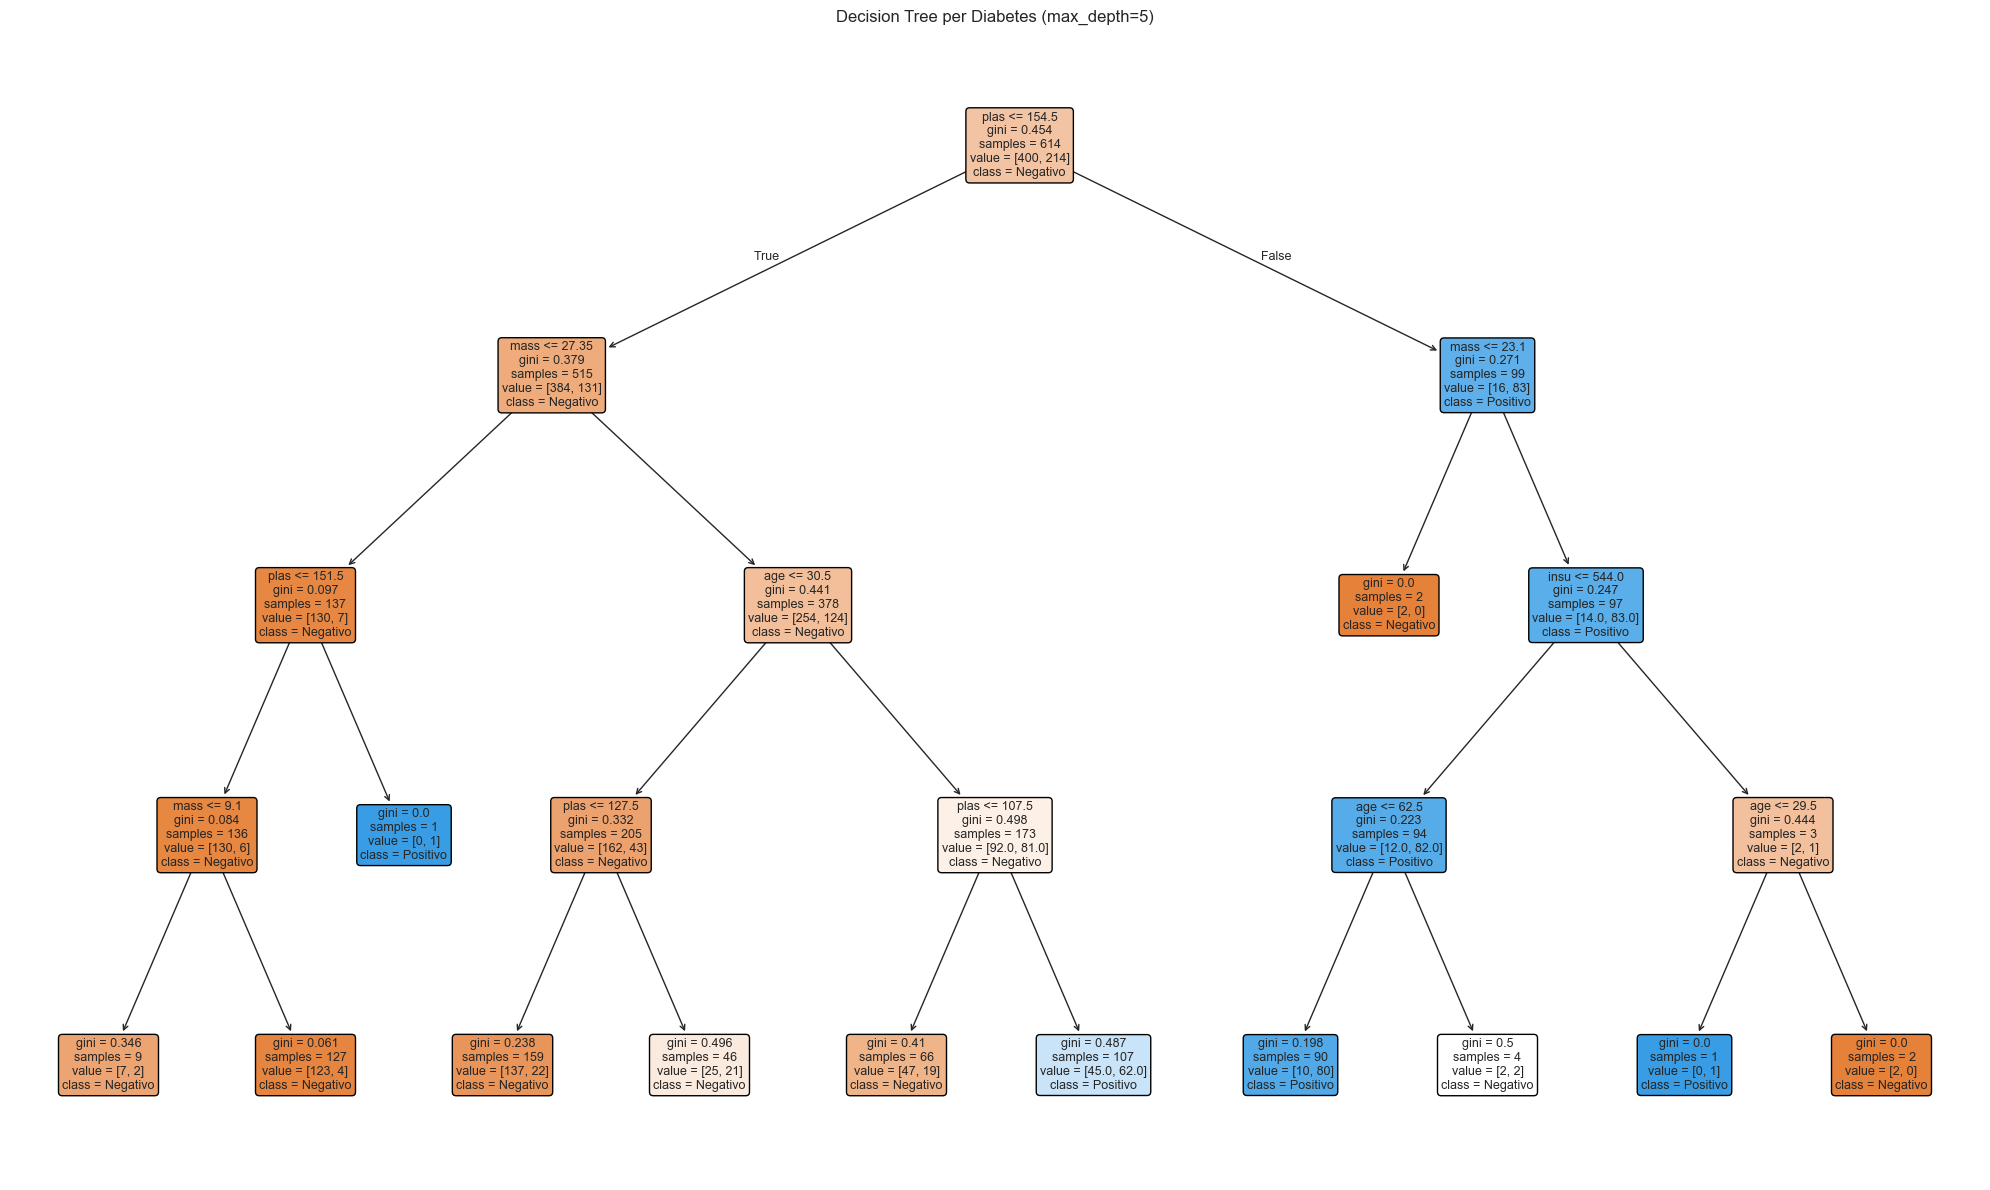

In [21]:
# Visualizzare l'albero con max_depth=5
plt.figure(figsize=(20, 12))
plot_tree(
    tree_depth,
    filled=True,
    rounded=True,
    fontsize=9,
    feature_names=list(X.columns),
    class_names=['Negativo', 'Positivo']
)
plt.title('Decision Tree per Diabetes (max_depth=5)')
plt.tight_layout()
plt.show()

**Come leggere l'albero:**
- Ogni nodo mostra la condizione di split (es. `plas <= 127.5`)
- `gini`: misura dell'impurità (0 = puro, 0.5 = massima incertezza per 2 classi)
- `samples`: quanti campioni arrivano a quel nodo
- `value`: distribuzione delle classi [negativi, positivi]
- `class`: la predizione se ci fermassimo lì

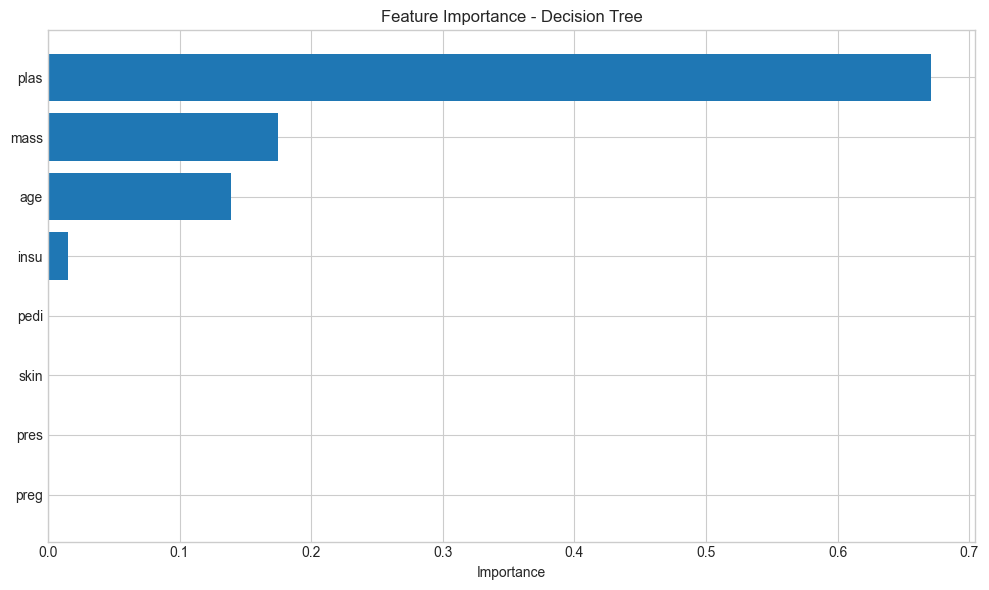


Features ordinate per importanza:
Feature  Importance
   plas    0.670911
   mass    0.174665
    age    0.138818
   insu    0.015606
   pedi    0.000000
   skin    0.000000
   pres    0.000000
   preg    0.000000


In [125]:
# Feature importance
# feature_importances_ restituisce un array con l'importanza di ogni feature calcolata dall'albero come la riduzione media dell'impurità
importances = tree_depth.feature_importances_

# Creare DataFrame e ordinare
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - Decision Tree')
plt.tight_layout()
plt.show()

print("\nFeatures ordinate per importanza:")
print(importance_df.sort_values('Importance', ascending=False).to_string(index=False))

**Interpretazione medica:**

Le features più importanti secondo il modello sono probabilmente:
- `plas` (glucosio): ha senso, è il test principale per il diabete
- `mass` (BMI): l'obesità è un fattore di rischio noto
- `age` (età): il rischio aumenta con l'età

Questo tipo di interpretabilità è prezioso in ambito medico: i clinici possono verificare se il modello sta usando features sensate.

---
## 8. Riepilogo

### Il problema dell'overfitting

Un albero senza limiti:
- Memorizza perfettamente il training set (100% accuracy)
- Ma generalizza male sui nuovi dati (~72%)
- Impara anche il rumore e le peculiarità dei dati di training

### Due soluzioni: Pre-pruning e Post-pruning

| Metodo | Come funziona | Parametri principali |
|--------|---------------|---------------------|
| **Pre-pruning** | Ferma la crescita prima che l'albero diventi troppo grande | max_depth, min_samples_split, min_samples_leaf |
| **Post-pruning** | Lascia crescere l'albero, poi taglia i rami che non contribuiscono abbastanza | ccp_alpha |


### Bonus: Interpretabilità

I Decision Trees ci permettono di:
- Visualizzare le regole decisionali
- Capire quali features sono importanti
- Spiegare le predizioni ai non-tecnici

Questo li rende particolarmente utili in ambiti dove la trasparenza è importante (medicina, finanza, legge).